<a href="https://colab.research.google.com/github/MidhulaMS/EV-Population-Prediction/blob/main/EV_Population_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

# Cross - validation, hyperparameter tuning (k-fold,grid)
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold

# Logistic Regression
from sklearn.linear_model import LogisticRegression
# k-NN
from sklearn.neighbors import KNeighborsClassifier
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Random Forest
from sklearn.ensemble import RandomForestClassifier


# Bagging
from sklearn.ensemble import BaggingClassifier
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
# Boosting
from sklearn.ensemble import AdaBoostClassifier

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# For evaluating Mode
from statistics import mode

# For min max scaling
from sklearn.preprocessing import MinMaxScaler
#for Gridsearch
from sklearn.model_selection import GridSearchCV


# ANN
#import keras
from keras.models import Sequential
from keras.layers import Dense

# Reading Data

In [ ]:
filepath =  "/content/drive/MyDrive/AI ML/Data/washington_EV.csv"


In [ ]:
EV_df = pd.read_csv(filepath)


# Exploratory data analysis (EDA)


In [ ]:
EV_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287763 entries, 0 to 287762
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         287763 non-null  object 
 1   County                                             287754 non-null  object 
 2   City                                               287754 non-null  object 
 3   State                                              287763 non-null  object 
 4   Postal Code                                        287754 non-null  float64
 5   Model Year                                         287763 non-null  int64  
 6   Make                                               287763 non-null  object 
 7   Model                                              287763 non-null  object 
 8   Electric Vehicle Type                              287763 non-null  object

In [ ]:
EV_df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,277607004,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,21.0,478641796,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,35.0,253249678,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,2.0,131872905,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,7SAYGDEE2P,Snohomish,Bothell,WA,98012.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,260935657,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,5.306105e+10


In [ ]:
# Numerical Data - Electric Range
# Categorical Data - County,City,State,postal code,Make,Model,ElectricVehicleType,Model Year,CAFV,Eligibility,Electric Utility,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
# Identifiers- VIN,DOL Vehicle ID

In [ ]:
EV_df.shape

(287763, 16)

In [ ]:
EV_df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,287754.000000,287763.000000,287754.000000,287023.000000,2.877630e+05,2.877540e+05
mean,98174.889729,2022.207299,37.828697,28.849608,2.486886e+08,5.296750e+10
std,2638.364484,3.075325,77.223589,14.889125,6.293818e+07,1.691737e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.258425e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.658514e+08,5.303303e+10
75%,98387.000000,2024.000000,32.000000,42.000000,2.820231e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [ ]:
# Electric Range minimum value is "0" which needs to be inspected.

In [ ]:
EV_df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

### finding missing values

In [ ]:
EV_df.isna().sum()

,0
VIN (1-10),0
County,9
City,9
State,0
Postal Code,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [ ]:
EV_df.duplicated().sum()

np.int64(0)

In [ ]:
EV_df['Electric Vehicle Type'].unique()

array(['Plug-in Hybrid Electric Vehicle (PHEV)',
       'Battery Electric Vehicle (BEV)'], dtype=object)

In [ ]:
EV_df.nunique()

,0
VIN (1-10),17690
County,256
City,931
State,53
Postal Code,1166
Model Year,23
Make,48
Model,196
Electric Vehicle Type,2
Clean Alternative Fuel Vehicle (CAFV) Eligibility,3


In [ ]:
EV_df["Electric Vehicle Type"].value_counts(dropna=False)

,count
Electric Vehicle Type,
Battery Electric Vehicle (BEV),232271
Plug-in Hybrid Electric Vehicle (PHEV),55492


In [ ]:
EV_df.duplicated().sum()

np.int64(0)

In [ ]:
EV_df["Electric Vehicle Type"].isnull().sum()

np.int64(0)

## Visual EDA(Plotting)

### Univariate analysis

In [ ]:
numerical_features = [
    "Electric Range"
]

categorical_features = [
    "County",
    "City",
    "State",
    "Postal Code",
    "Model Year",
    "Make",
    "Model",
    "Electric Vehicle Type",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility",
    "Legislative District",
    "Electric Utility",
    "Vehicle Location",
    "2020 Census Tract"
]

identifier_features = [
    "VIN (1-10)",
    "DOL Vehicle ID"
]

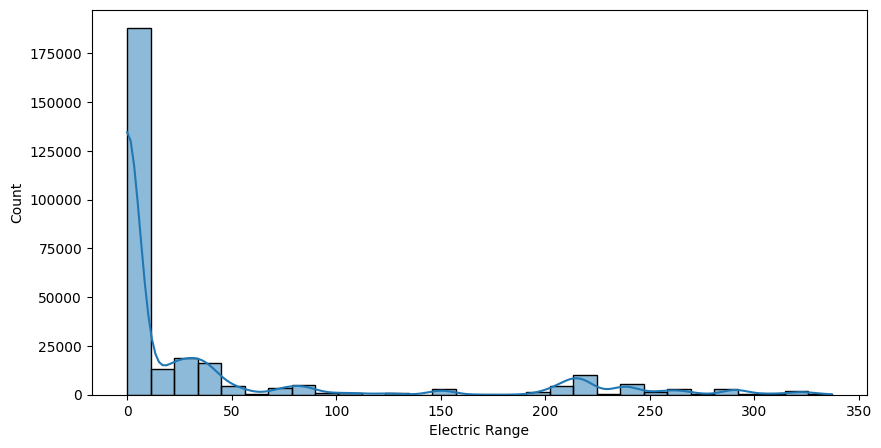

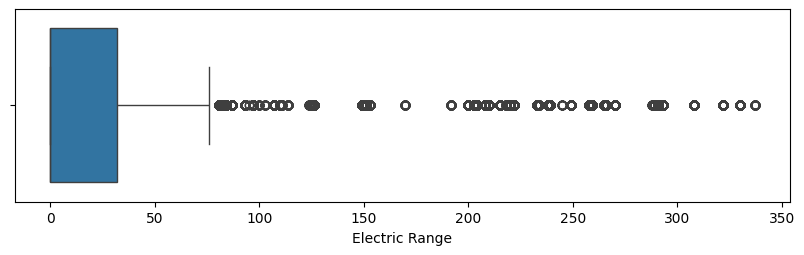

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(EV_df["Electric Range"], kde=True, bins=30)
plt.show()

plt.figure(figsize=(10,2.5))
sns.boxplot(x=EV_df["Electric Range"])
plt.show()

In [ ]:
# Data is right skewed since the right whiskers is longer.
# Electric Range contains several high-value outliers.But high range vehicles need to be investigated before treating them as outliers.

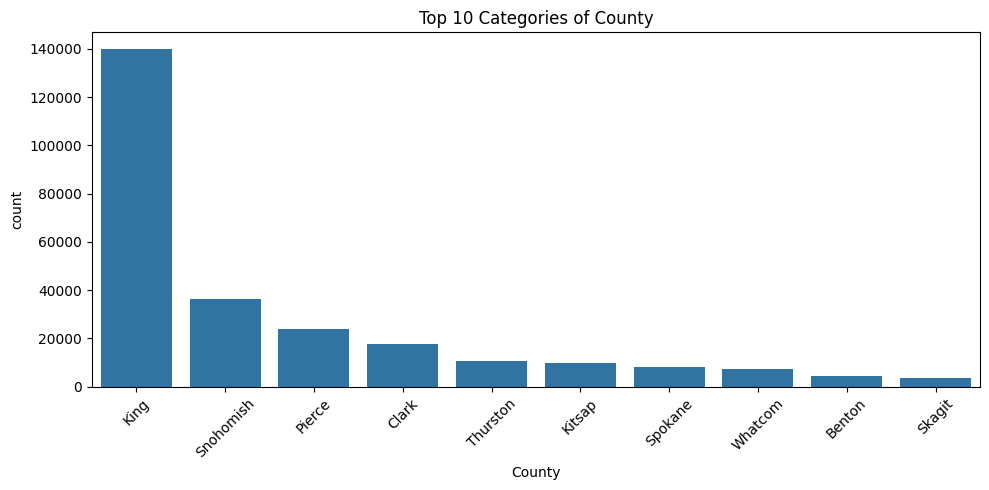

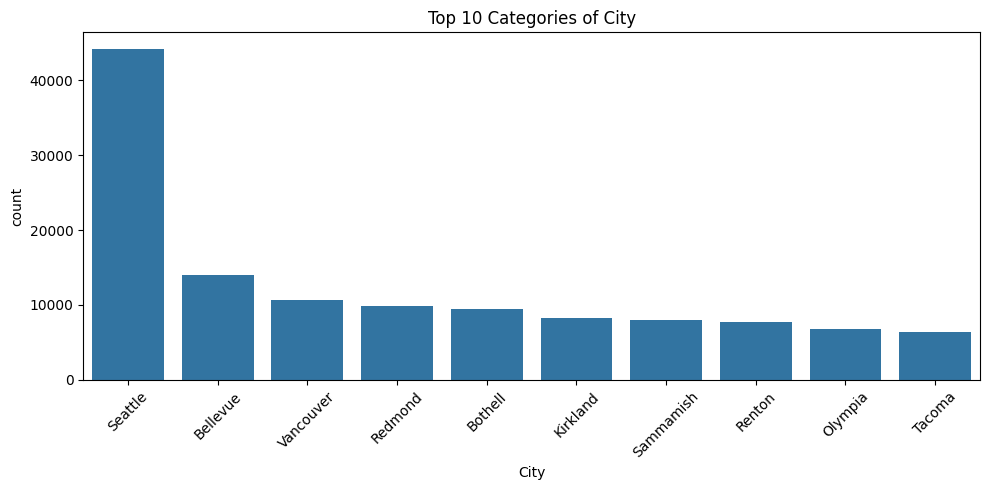

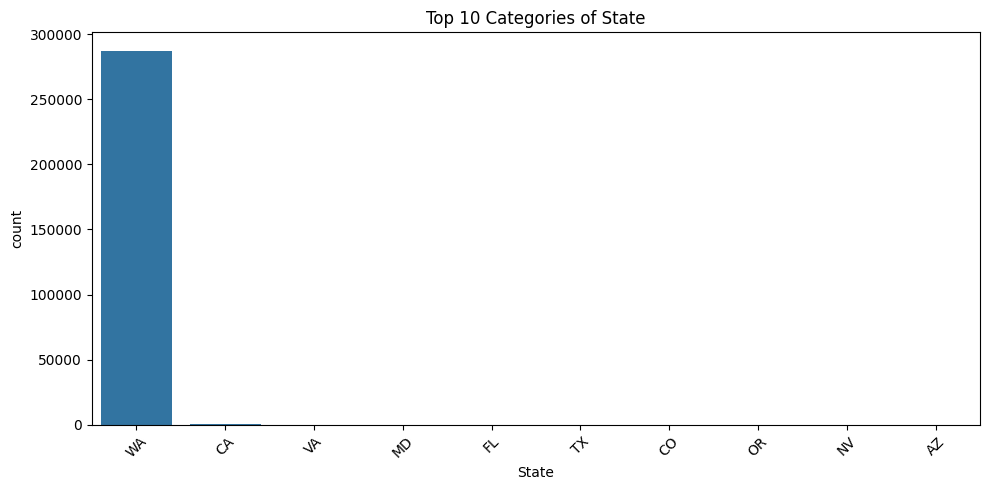

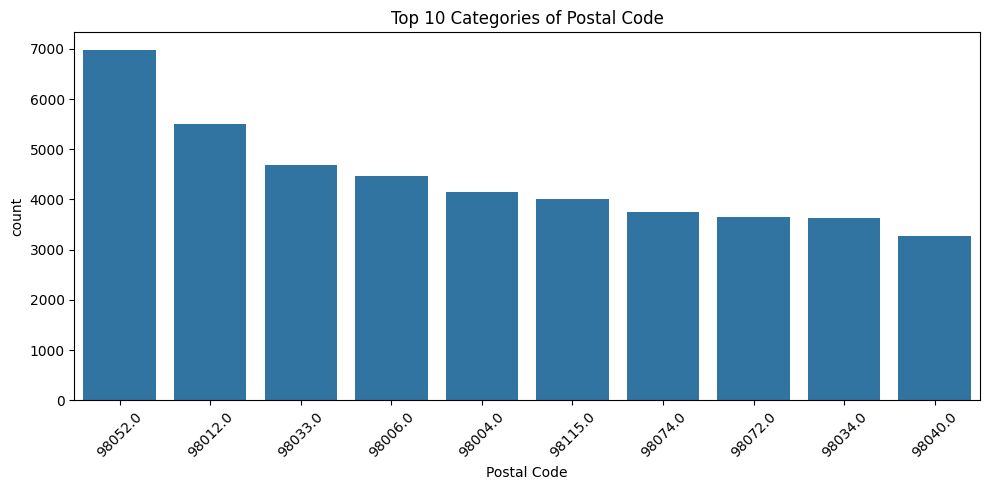

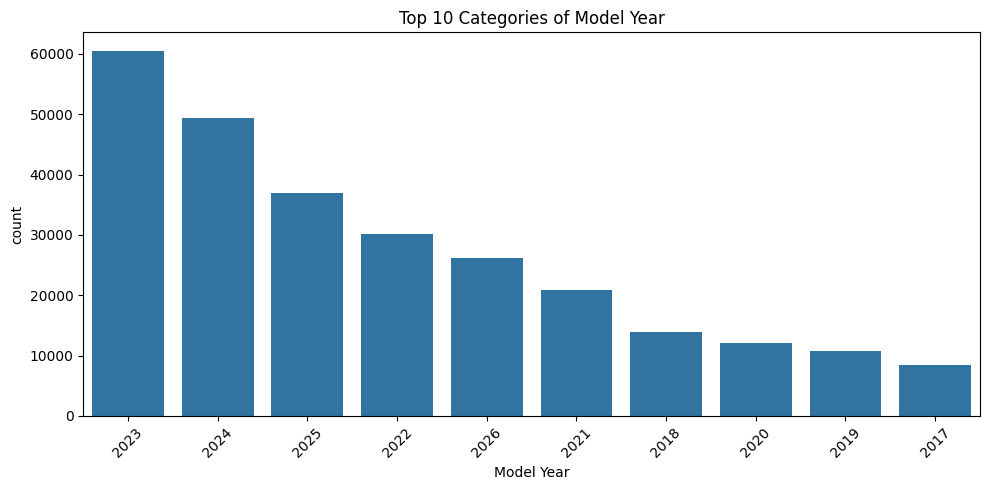

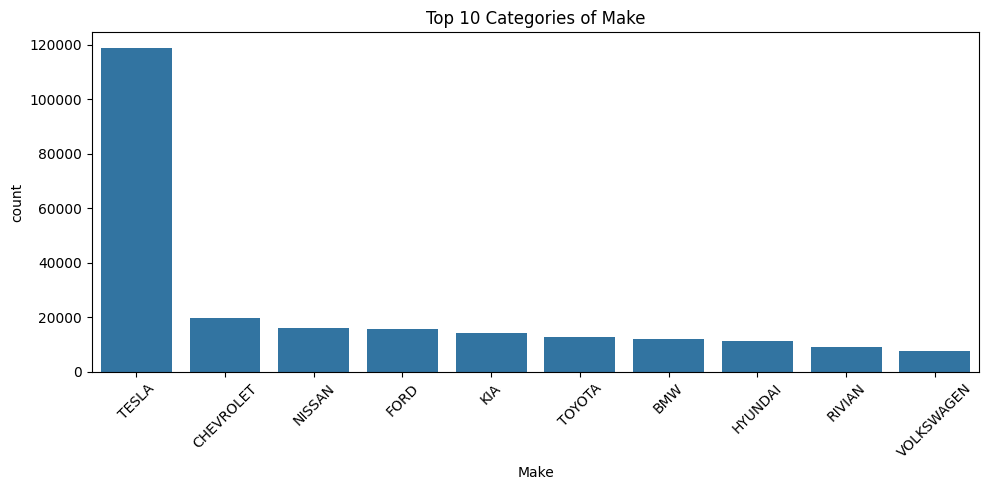

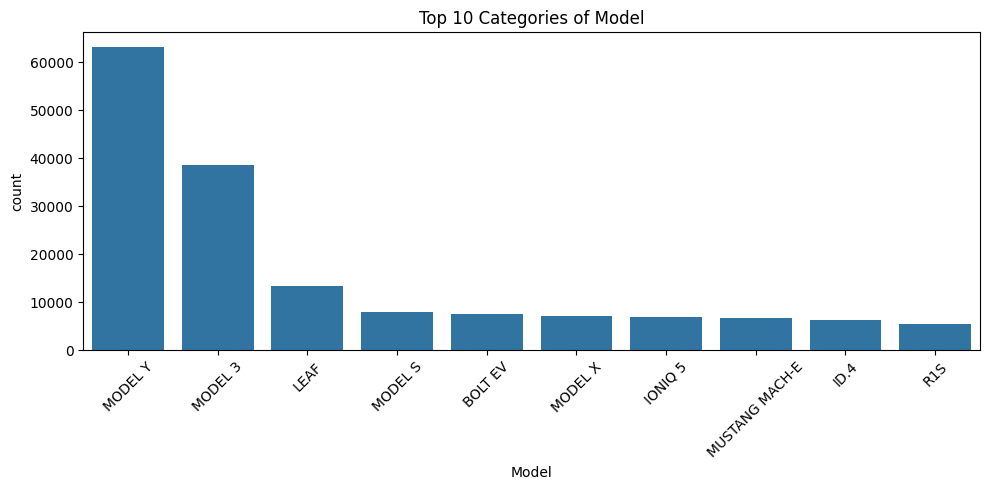

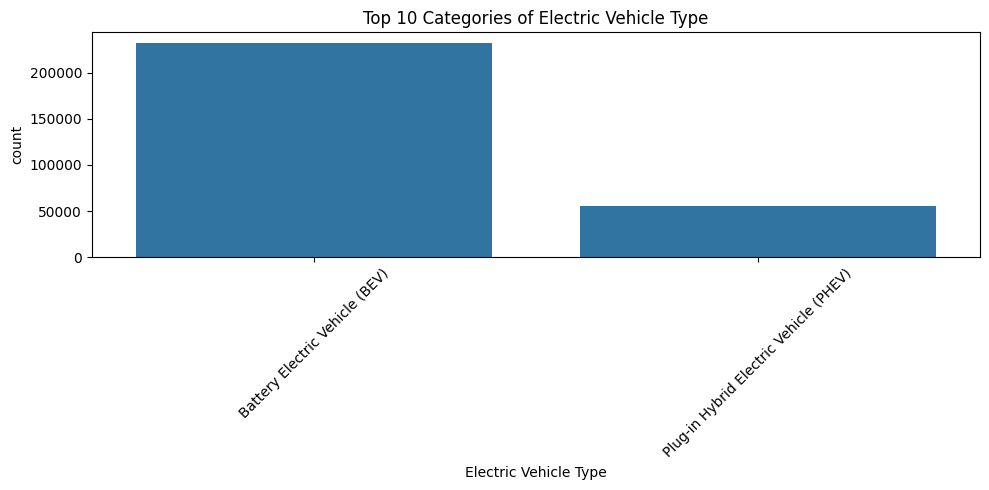

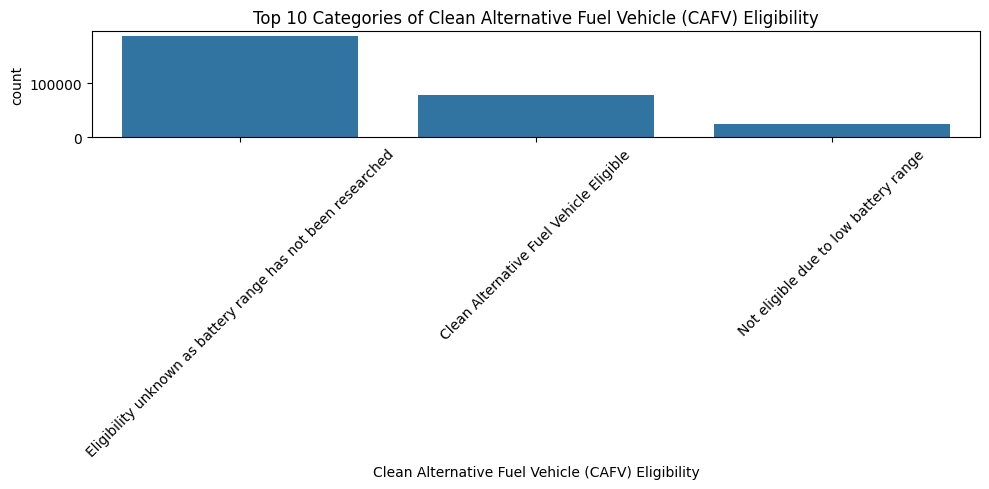

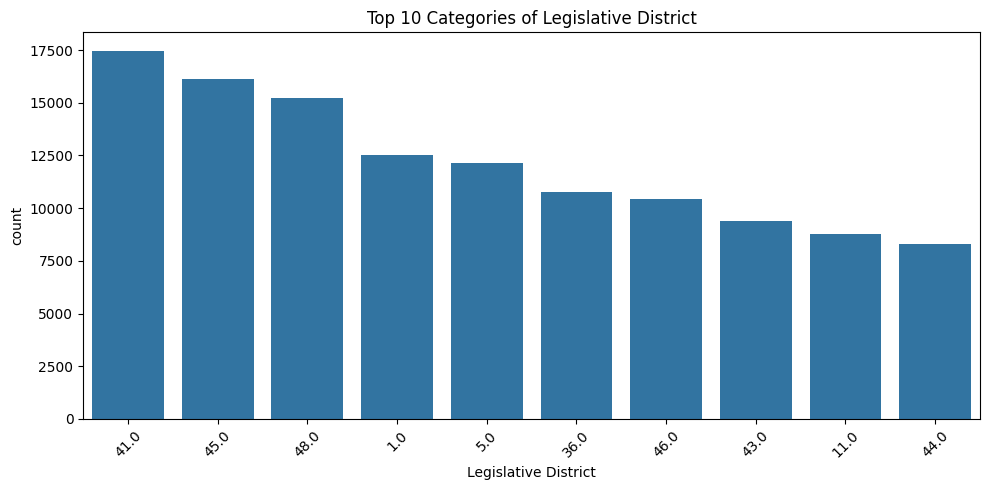

/tmp/ipykernel_902/2614859388.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


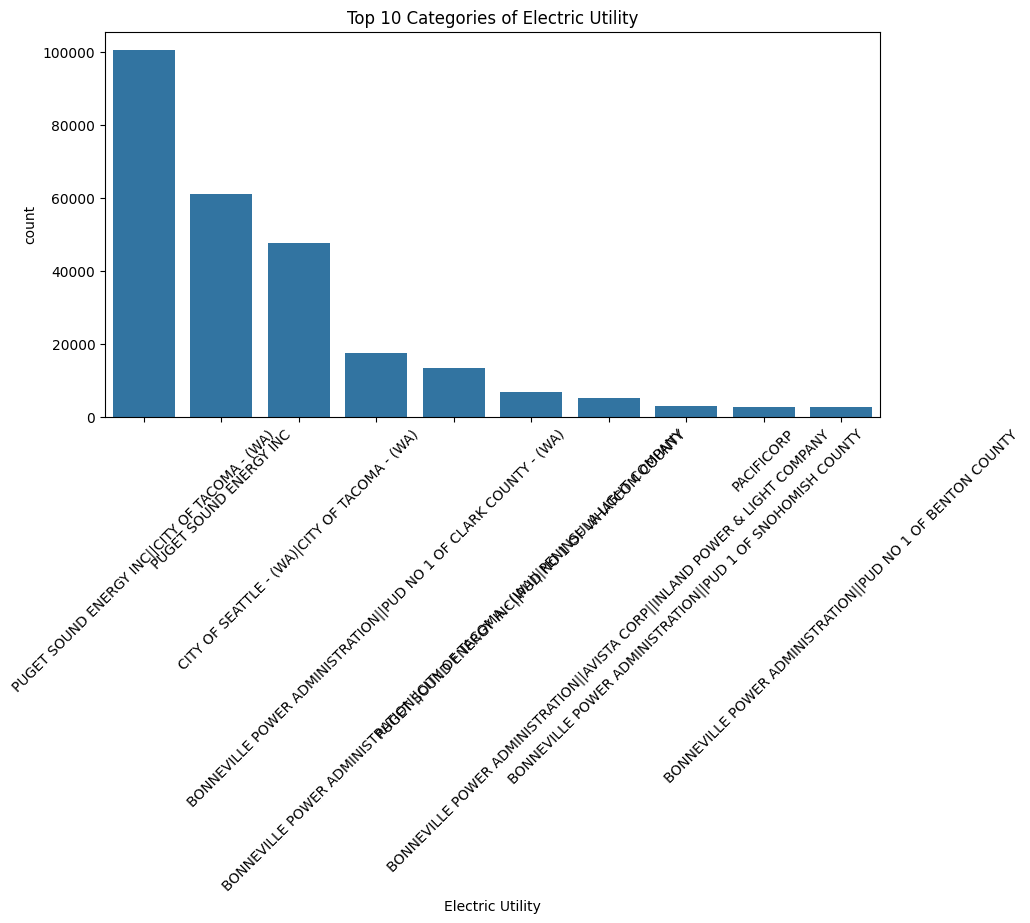

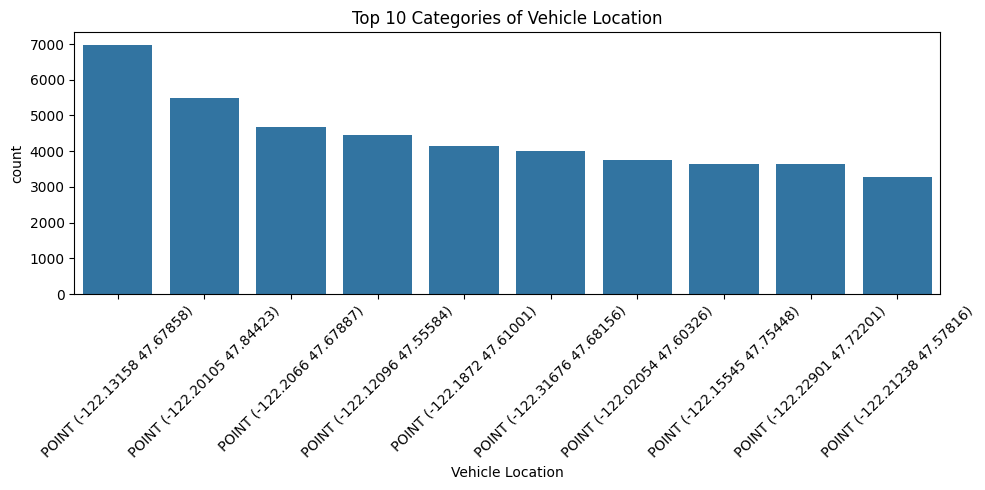

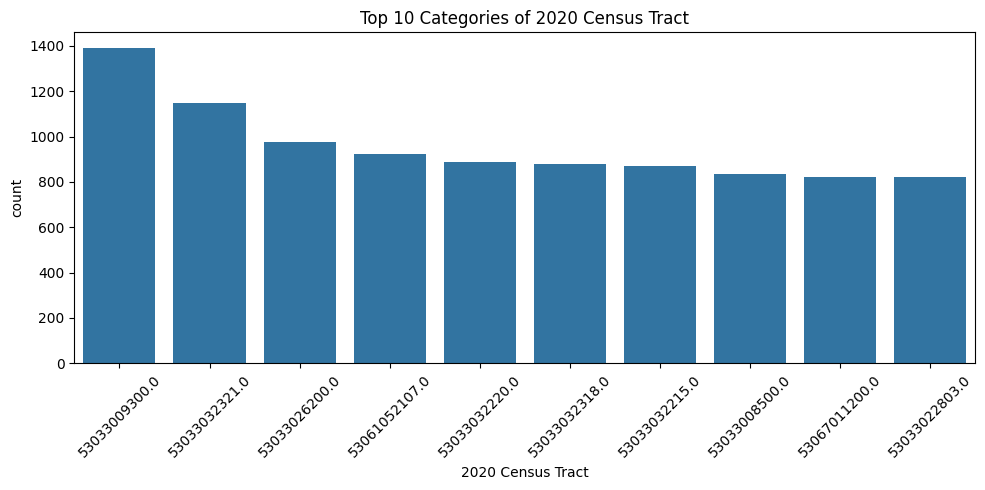

In [ ]:
for col in categorical_features:

    plt.figure(figsize=(10,5))

    top10 = EV_df[col].value_counts().head(10).index

    sns.countplot(
        data=EV_df,
        x=col,
        order=top10
    )

    plt.title(f"Top 10 Categories of {col}")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [ ]:
# From observing Categorical data we understands:
#In 'States' only one state exists this feature has no variation.

### Bivariate Analysis

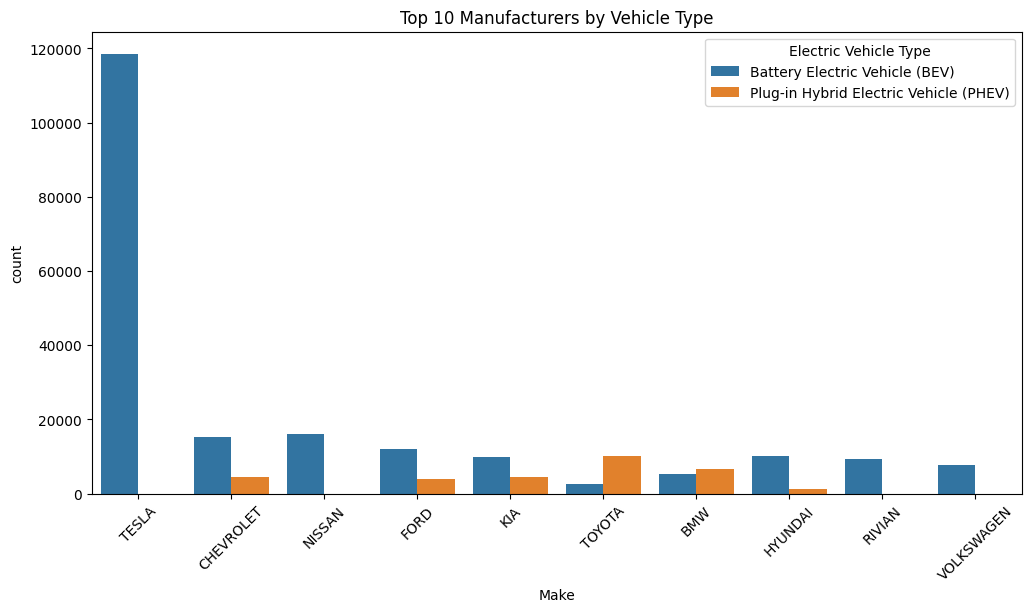

In [ ]:
plt.figure(figsize=(12,6))

top10 = EV_df["Make"].value_counts().head(10).index

sns.countplot(
    data=EV_df[EV_df["Make"].isin(top10)],
    x="Make",
    hue="Electric Vehicle Type",
    order=top10
)

plt.xticks(rotation=45)
plt.title("Top 10 Manufacturers by Vehicle Type")
plt.show()

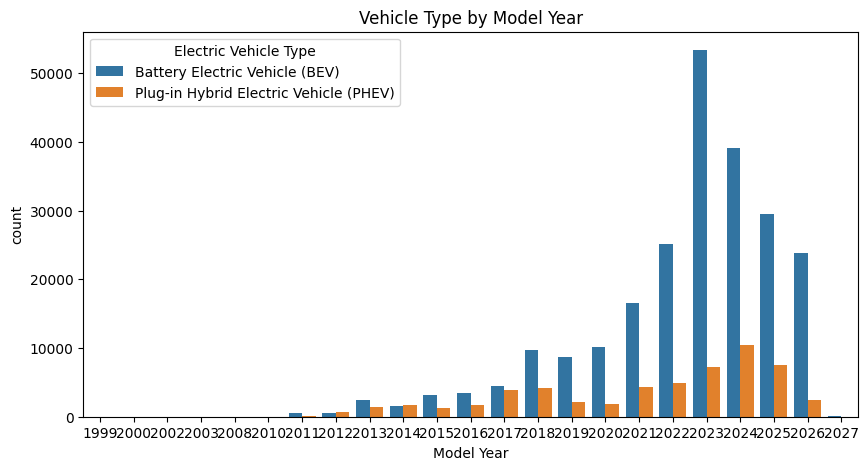

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=EV_df,
    x="Model Year",
    hue="Electric Vehicle Type"
)

plt.title("Vehicle Type by Model Year")
plt.show()

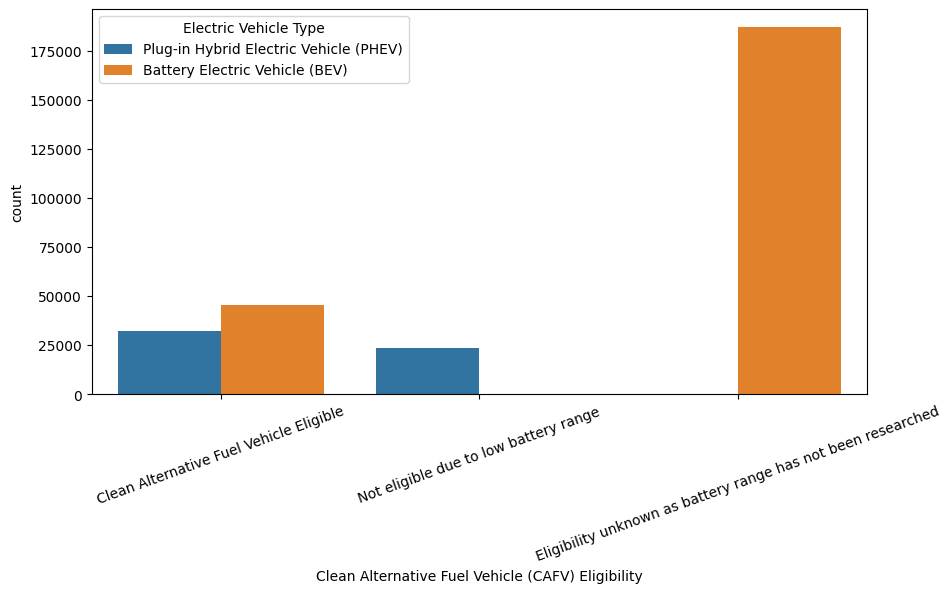

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=EV_df,
    x="Clean Alternative Fuel Vehicle (CAFV) Eligibility",
    hue="Electric Vehicle Type"
)

plt.xticks(rotation=20)
plt.show()

In [ ]:
#Model Year is strongly associated with Electric Vehicle Type and should be retained as a predictive feature.

### correlaton heatmap

In [ ]:
#A correlation heatmap was not generated because the dataset contains only one continuous numerical feature

# Data preprocessing

## Data Cleaning

In [ ]:
# Removing (VIN (1-10), DOL Vehicle ID)-Identifiers no importance in prediction.
# State - Unique Value repeated.
# Vehicle Location - Too many unique values
# 2020 Census tract,Postal code - Behaves like a identifier

In [ ]:
drop_cols = [
    "VIN (1-10)",
    "DOL Vehicle ID",
    "State",
    "Vehicle Location","Postal Code",
    "2020 Census Tract"
]

EV_df = EV_df.drop(columns=drop_cols)

### Missing Value Handling

In [ ]:
EV_df.isnull().sum()  #Check missing values

,0
County,9
City,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0
Electric Range,9
Legislative District,740
Electric Utility,9


In [ ]:
missing = EV_df.isnull().sum()

missing_percentage = (missing / len(EV_df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
}).sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Legislative District,740,0.257156
County,9,0.003128
City,9,0.003128
Electric Range,9,0.003128
Electric Utility,9,0.003128
Model Year,0,0.000000
Electric Vehicle Type,0,0.000000
Model,0,0.000000
Make,0,0.000000
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0,0.000000


In [ ]:
# Fill categorical columns with mode
cat_fill = [
    "County",
    "City",
    "Electric Utility",
    "Legislative District"
]

for col in cat_fill:
    EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)
EV_df.isnull().sum()



/tmp/ipykernel_902/876020920.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)


,0
County,0
City,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0
Electric Range,9
Legislative District,0
Electric Utility,0


In [ ]:
for col in cat_fill:
    EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)

# Fill numerical column with median
EV_df["Electric Range"].fillna(
    EV_df["Electric Range"].median(),
    inplace=True
)
EV_df.isnull().sum()

/tmp/ipykernel_902/4250564942.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)
/tmp/ipykernel_902/4250564942.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

,0
County,0
City,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0
Electric Range,0
Legislative District,0
Electric Utility,0


### Handling Duplicates

In [ ]:
duplicate_rows = EV_df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 217716


In [ ]:
EV_df = EV_df.drop_duplicates()
# Removed all duplicate columns

## Outlier Handling

In [ ]:
# Using the IQR method
Q1 = EV_df['Electric Range'].quantile(0.25)
Q3 = EV_df['Electric Range'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Q1: 0.0, Q3: 38.0, IQR: 38.0
Lower bound: -57.0, Upper bound: 95.0


In [ ]:
outliers = EV_df[
    (EV_df['Electric Range'] < lower_bound) |
    (EV_df['Electric Range'] > upper_bound)
]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 9113


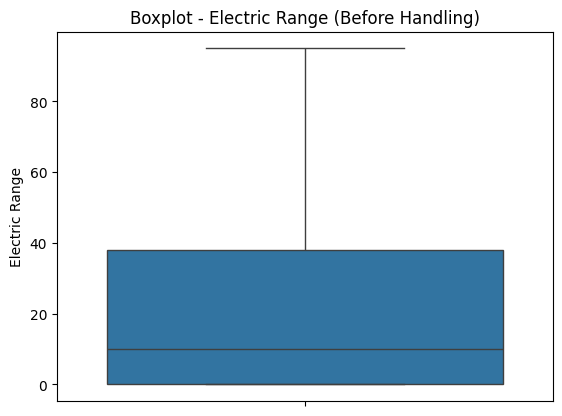

In [ ]:
EV_df['Electric Range'] = EV_df['Electric Range'].clip(
    lower=lower_bound, upper=upper_bound)


# Checking whether the Outliers were clipped
sns.boxplot(EV_df['Electric Range'])
plt.title('Boxplot - Electric Range (Before Handling)')
plt.show()

# Data Transformation

## Scaling

In [ ]:
# Numerical columns
num_cols = EV_df.select_dtypes(include = ['int64', 'float64']).columns
num_cols

Index(['Model Year', 'Electric Range', 'Legislative District'], dtype='object')

In [ ]:
# Categorical Columns
cat_cols = EV_df.select_dtypes(include = ['object']).columns
cat_cols

Index(['County', 'City', 'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
       'Electric Utility'],
      dtype='object')

### Min-Max Scaling : Scaling technique that transforms data into a fixed range, usually 0 to 1.

In [ ]:
skewed_cols =['Model Year','Electric Range']

In [ ]:
# Before min max scaling
EV_df.head(2)

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Electric Utility
0,Kitsap,Bremerton,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,PUGET SOUND ENERGY INC
1,Snohomish,Lynnwood,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,95.0,21.0,PUGET SOUND ENERGY INC


In [ ]:
# object for min-max scaling
minmax_scaler = MinMaxScaler()
EV_df[skewed_cols] = minmax_scaler.fit_transform(EV_df[skewed_cols])

In [ ]:
# After min max scaling
EV_df.head(2)

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Electric Utility
0,Kitsap,Bremerton,0.928571,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,0.336842,23.0,PUGET SOUND ENERGY INC
1,Snohomish,Lynnwood,0.714286,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,1.000000,21.0,PUGET SOUND ENERGY INC


## Encoding

In [ ]:
# Categorical Columns
cat_cols = EV_df.select_dtypes(include = ['object']).columns
cat_cols

Index(['County', 'City', 'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
       'Electric Utility'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    EV_df[col] = le.fit_transform(EV_df[col].astype(str))
    label_encoders[col] = le
EV_df.head()

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Electric Utility
0,121,87,0.928571,46,192,1,0,0.336842,23.0,74
1,213,471,0.714286,41,111,0,0,1.000000,21.0,74
2,121,652,0.500000,14,32,1,2,0.200000,35.0,74
3,234,926,0.535714,41,112,0,0,1.000000,2.0,74
4,213,81,0.857143,41,114,0,1,0.000000,1.0,74


# Model Building

## Data Splitting


In [ ]:
y = EV_df['Electric Vehicle Type']
X = EV_df.drop(columns = ['Electric Vehicle Type'], axis = 1)

# split into train-test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =33)


##Model Building Using Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier()
# Train the model
dt_model.fit(X_train, y_train)
# Make predictions using the model
dt_pred = dt_model.predict(X_test)
# Evaluate the model performance
acc_dt = accuracy_score(y_test, dt_pred)
recall_dt = recall_score(y_test, dt_pred, average='weighted')
precision_dt = precision_score(y_test, dt_pred, average='weighted')
f1_dt = f1_score(y_test, dt_pred, average='weighted')
print(" Accuracy of Decision Tree: ", acc_dt)
print(" Recall of Decision Tree: ", recall_dt)
print(" Precision of Decision Tree: ", precision_dt)
print(" F1 Score of Decision Tree: ", f1_dt)

 Accuracy of Decision Tree:  0.9972162740899357
 Recall of Decision Tree:  0.9972162740899357
 Precision of Decision Tree:  0.9972159128533259
 F1 Score of Decision Tree:  0.9972156348510562


In [ ]:
cm = confusion_matrix(y_test,dt_pred)
print(cm)

[[9232   15]
 [  24 4739]]


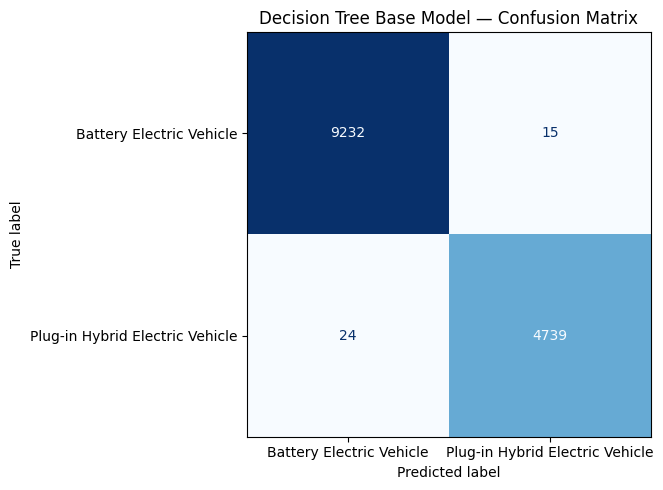

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Battery Electric Vehicle', 'Plug-in Hybrid Electric Vehicle']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title("Decision Tree Base Model — Confusion Matrix")
plt.tight_layout()
plt.show()

## Cross Validation of Decision Tree

### k-fold Cross Validation

In [ ]:
kf_obj = KFold(n_splits = 5, shuffle = True)

scores = cross_val_score(DecisionTreeClassifier(), X, y, cv = kf_obj)
print('Cross validation scores:',scores)
# print('Mean of cv scores:', np.mean(scores))
print('Mean of cv scores:', scores.mean())
print('Minimum cv:', scores.min())
print('Maximum cv:', scores.max())
diff = scores.max() - scores.min()
print('Difference b/w min and max cv:', diff)

Cross validation scores: [0.99685939 0.99807281 0.99743022 0.9967164  0.99750161]
Mean of cv scores: 0.9973160834864544
Minimum cv: 0.9967163966021844
Maximum cv: 0.9980728051391863
Difference b/w min and max cv: 0.0013564085370019185


### Grid Search Cross Validation

In [ ]:
# Define the parameters you want to check
para_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 4, 6]
}

# Build the model object
grid = GridSearchCV(
    DecisionTreeClassifier(),
    para_grid,
    cv=5,
    scoring='accuracy'
)

# Train the model
grid.fit(X_train, y_train)

# Display the best parameters and score
print('Best parameters are:', grid.best_params_)
print('Best cross validation score is:', grid.best_score_)

# Build the model using the best parameters identified
dT_model_HPT = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=2
)

# Train the model
dT_model_HPT.fit(X_train, y_train)

# Make predictions using the model
y_pred_dT_HPT = dT_model_HPT.predict(X_test)

# Evaluate the model performance
acc_dT_HPT = accuracy_score(y_test, y_pred_dT_HPT)

print('Accuracy:', acc_dT_HPT)

Best parameters are: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Best cross validation score is: 0.9981976203819285
Accuracy: 0.998429693076374


### Randomized Search Cross Validation

In [ ]:
# Define the parameters to check
para_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 4, 6]
}

# Build the model object
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=para_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train the model
random_search.fit(X_train, y_train)

# Display the best parameters and score
print('Best parameters are:', random_search.best_params_)
print('Best cross validation score is:', random_search.best_score_)

# Build the model using the best parameters
dT_model_HPT = random_search.best_estimator_

# Make predictions using the model
y_pred_dT_HPT = dT_model_HPT.predict(X_test)

# Evaluate the model performance
acc_dT_HPT = accuracy_score(y_test, y_pred_dT_HPT)

print('Accuracy:', acc_dT_HPT)

Best parameters are: {'min_samples_split': 2, 'max_depth': 6, 'criterion': 'entropy'}
Best cross validation score is: 0.9981976203819285
Accuracy: 0.998429693076374


## Hyper Parameter Tuning : Using Grid Search CV

In [ ]:
# Define the parameters to check
para_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 4, 6]
}

# Build the model object
grid_search = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid=para_grid,
    cv=5,
    scoring='accuracy'
)

# Train the model
grid_search.fit(X_train, y_train)

# Display the best parameters and cross-validation score
print('Best parameters are:', grid_search.best_params_)
print('Best cross validation score is:', grid_search.best_score_)

# Get the best model
dT_model_HPT = grid_search.best_estimator_

# Make predictions using the best model
y_pred_dT_HPT = dT_model_HPT.predict(X_test)

# Evaluate the model performance
acc_dT_HPT = accuracy_score(y_test, y_pred_dT_HPT)

print('Accuracy:', acc_dT_HPT)

Best parameters are: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Best cross validation score is: 0.9981976203819285
Accuracy: 0.998429693076374


## Boosting using Decision tree

In [ ]:
# build the model object
ada_boosting_model = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(), n_estimators = 25, learning_rate = 1)
# Training model
ada_boosting_model.fit(X_train, y_train)
# Make predictions using the model
ada_predict = ada_boosting_model.predict(X_test)
# Evaluate the model performance
acc_ada_boosting = accuracy_score(y_test, ada_predict)
prec_ada_boosting = precision_score(y_test, ada_predict, average='weighted')
recall_ada_boosting = recall_score(y_test, ada_predict, average='weighted')
print("Accuracy of Adaptive Boosting Classifier using accuracy score", acc_ada_boosting)
print("Accuracy of Adaptive Boosting Classifier using precision score", prec_ada_boosting)
print("Accuracy of Adaptive Boosting Classifier using recall score", recall_ada_boosting)

Accuracy of Adaptive Boosting Classifier using accuracy score 0.9972162740899357
Accuracy of Adaptive Boosting Classifier using precision score 0.9972161436623524
Accuracy of Adaptive Boosting Classifier using recall score 0.9972162740899357


##Model Building Using KNN

In [ ]:
#build the model obj
kNN = KNeighborsClassifier(n_neighbors=4)
#train the model
kNN.fit(X_train,y_train)
#make prediction using the ,model
y_pred_kNN = kNN.predict(X_test)
#evaluate the model performance
acc_kNN = accuracy_score(y_test,y_pred_kNN)
print('Accuracy comparison')
print('**********')
print('Accuracy of KNN model:',acc_kNN)

Accuracy comparison
**********
Accuracy of KNN model: 0.8589578872234118


##Cross validation for KNN models

###K-Fold Cross Validation

In [ ]:
kf_obj = KFold(n_splits=5,shuffle=True,random_state=29)

scores = cross_val_score(kNN, X_train, y_train, cv=5, scoring='accuracy')
print('Cross-validation scores:', scores)
print('Mean CV accuracy:', np.mean(scores))

Cross-validation scores: [0.84769807 0.84145253 0.84973677 0.8438476  0.84188454]
Mean CV accuracy: 0.8449239020146925


###Grid Search Cross Validation

In [ ]:
# --- Cross validation to find best k ---
param_grid = {'n_neighbors': list(range(1, 21))}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print('Best k:', grid_search.best_params_)
print('Best CV accuracy:', grid_search.best_score_)

# Use the best model found
best_kNN = grid_search.best_estimator_
y_pred_kNN = best_kNN.predict(X_test)

acc_kNN = accuracy_score(y_test, y_pred_kNN)
print('Accuracy of best KNN model:', acc_kNN)

Best k: {'n_neighbors': 1}
Best CV accuracy: 0.9052054925521655
Accuracy of best KNN model: 0.9203426124197002


###Randomized Search Cross Validation


In [ ]:
# Define the parameters to check
para_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Build the model object
random_search = RandomizedSearchCV(KNeighborsClassifier(),
    param_distributions=para_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train the model
random_search.fit(X_train, y_train)

# Display the best parameters and score
print('Best parameters are:', random_search.best_params_)
print('Best cross validation score is:', random_search.best_score_)

# Build the model using the best parameters
kNN_model_HPT = random_search.best_estimator_

# Make predictions using the model
y_pred_kNN_HPT = kNN_model_HPT.predict(X_test)

# Evaluate the model performance
acc_kNN_HPT = accuracy_score(y_test, y_pred_kNN_HPT)

print('Accuracy:', acc_kNN_HPT)

Best parameters are: {'weights': 'distance', 'n_neighbors': 8, 'metric': 'manhattan'}
Best cross validation score is: 0.9151096885059665
Accuracy: 0.9261241970021413


## Hyper Parameter Tuning : Using Grid Search CV

In [ ]:
# Define the parameters to check
para_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Build the model object
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=para_grid,
    cv=5,
    scoring='accuracy'
)

# Train the model
grid_search.fit(X_train, y_train)

# Display the best parameters and cross-validation score
print('Best parameters are:', grid_search.best_params_)
print('Best cross validation score is:', grid_search.best_score_)

# Get the best model
knn_model_HPT = grid_search.best_estimator_

# Make predictions using the best model
y_pred_knn_HPT = knn_model_HPT.predict(X_test)

# Evaluate the model performance
acc_knn_HPT = accuracy_score(y_test, y_pred_knn_HPT)

print('Accuracy:', acc_knn_HPT)

Best parameters are: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best cross validation score is: 0.91502042830756
Accuracy: 0.9265524625267666


###Bagging using KNN

In [ ]:
# build the model object
bM_model = BaggingClassifier(KNeighborsClassifier())
#train the model
bM_model.fit(X_train, y_train)
# make predictions using the model
y_pred_bM = bM_model.predict(X_test)
#evaluate the model performance
acc_BM =accuracy_score(y_test,y_pred_bM)
print("Accuracy of Bagging Model:",acc_BM)

Accuracy of Bagging Model: 0.8582441113490364


##Logistic Regression


In [ ]:
# Build the Logistic Regression model
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000,

)

# Train the model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg.predict(X_test)

# Model Evaluation
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
prec_log_reg = precision_score(y_test, y_pred_log_reg)
rec_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

# Display Results
print("========== Logistic Regression ==========")
print(f"Accuracy : {acc_log_reg:.4f}")
print(f"Precision: {prec_log_reg:.4f}")
print(f"Recall   : {rec_log_reg:.4f}")
print(f"F1 Score : {f1_log_reg:.4f}")

========== Logistic Regression ==========
Accuracy : 0.7662
Precision: 0.7615
Recall   : 0.4545
F1 Score : 0.5693


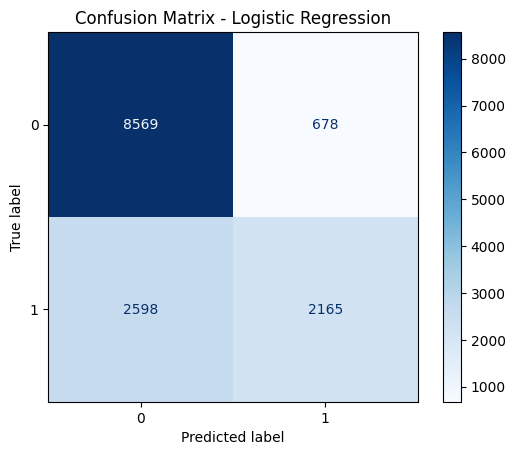

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log_reg,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
#Confusion Matrix Analysis:
#The Logistic Regression model correctly classified 8,569 BEVs and 2,165 PHEVs.
#However, it misclassified 2,598 PHEVs as BEVs, indicating that the model struggles to identify the minority class
#This is reflected in the relatively low recall score despite achieving an overall accuracy of 76.62%

##Cross Validation for Logistic Regression

###K-fold for Logistic Regression


In [ ]:

cv_scores = cross_val_score(
    log_reg,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.76284797 0.7698965  0.76086375 0.76470063 0.7595253 ]
Mean Accuracy: 0.7635668288664542
Standard Deviation: 0.0036196045504352527


### Grid Search CV for Logistic Regression

In [ ]:
# Define the parameters to search
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Build the Grid Search object
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

# Train the Grid Search
grid.fit(X_train, y_train)

# Display the best parameters and CV score
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

# ============================================
# Build the Logistic Regression model using
# the best parameters
# ============================================

log_reg_HPT = LogisticRegression(
    C=grid.best_params_['C'],
    penalty=grid.best_params_['penalty'],
    solver=grid.best_params_['solver'],
    max_iter=1000,
    random_state=42
)

# Train the model
log_reg_HPT.fit(X_train, y_train)

# Make predictions
y_pred_log_reg_HPT = log_reg_HPT.predict(X_test)

# Evaluate the model
acc_log_reg_HPT = accuracy_score(y_test, y_pred_log_reg_HPT)
prec_log_reg_HPT = precision_score(y_test, y_pred_log_reg_HPT)
rec_log_reg_HPT = recall_score(y_test, y_pred_log_reg_HPT)
f1_log_reg_HPT = f1_score(y_test, y_pred_log_reg_HPT)

# Display results
print("Accuracy :", acc_log_reg_HPT)
print("Precision:", prec_log_reg_HPT)
print("Recall   :", rec_log_reg_HPT)
print("F1 Score :", f1_log_reg_HPT)

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross Validation Score: 0.7750235462604406
Accuracy : 0.7748037116345468
Precision: 0.7782006920415225
Recall   : 0.47218139827839595
F1 Score : 0.5877433686136155


### RandomizedSearchCV for Logistic Regression

In [ ]:
# Define the parameter distribution
param_dist = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Build the Randomized Search object
random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train the Randomized Search
random_search.fit(X_train, y_train)

# Display the best parameters and CV score
print("Best Parameters:", random_search.best_params_)
print("Best Cross Validation Score:", random_search.best_score_)


# Build the Logistic Regression model using

log_reg_RS = LogisticRegression(
    C=random_search.best_params_['C'],
    penalty=random_search.best_params_['penalty'],
    solver=random_search.best_params_['solver'],
    max_iter=1000,
    random_state=42
)

# Train the model
log_reg_RS.fit(X_train, y_train)

# Make predictions
y_pred_log_reg_RS = log_reg_RS.predict(X_test)

# Evaluate the model
acc_log_reg_RS = accuracy_score(y_test, y_pred_log_reg_RS)
prec_log_reg_RS = precision_score(y_test, y_pred_log_reg_RS)
rec_log_reg_RS = recall_score(y_test, y_pred_log_reg_RS)
f1_log_reg_RS = f1_score(y_test, y_pred_log_reg_RS)

# Display results
print("Accuracy :", acc_log_reg_RS)
print("Precision:", prec_log_reg_RS)
print("Recall   :", rec_log_reg_RS)
print("F1 Score :", f1_log_reg_RS)

Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.01}
Best Cross Validation Score: 0.7750235462604406
Accuracy : 0.7748037116345468
Precision: 0.7782006920415225
Recall   : 0.47218139827839595
F1 Score : 0.5877433686136155


### Ensemble for Logistic Regression

In [ ]:

# Bagging Classifier - Logistic Regression


# Build the Bagging model
bagging_log_reg = BaggingClassifier(
    estimator=LogisticRegression(
        C=0.01,
        penalty='l2',
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ),
    n_estimators=10,
    random_state=42
)

# Train the model
bagging_log_reg.fit(X_train, y_train)

# Make predictions
y_pred_bagging = bagging_log_reg.predict(X_test)

# Evaluate the model
acc_bagging = accuracy_score(y_test, y_pred_bagging)
prec_bagging = precision_score(y_test, y_pred_bagging)
rec_bagging = recall_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging)

# Display results
print("Accuracy :", acc_bagging)
print("Precision:", prec_bagging)
print("Recall   :", rec_bagging)
print("F1 Score :", f1_bagging)

Accuracy : 0.7763740185581728
Precision: 0.7808407994486561
Recall   : 0.47575057736720555
F1 Score : 0.5912589693411611


### Model Building Using RandomForest

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("--- Random Forest ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

--- Random Forest ---
Accuracy:  0.9973
Precision: 0.9954
Recall:    0.9966
F1 Score:  0.9960

Confusion Matrix:
 [[9225   22]
 [  16 4747]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9247
           1       1.00      1.00      1.00      4763

    accuracy                           1.00     14010
   macro avg       1.00      1.00      1.00     14010
weighted avg       1.00      1.00      1.00     14010



### CrossValidation For RandomForest

#### K-Fold

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf, X, y, cv=skf, scoring='accuracy')

print("CV scores per fold:", cv_scores)
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV scores per fold: [0.99728765 0.99693076 0.99757299 0.99750161 0.99750161]
Mean CV accuracy: 0.9974 (+/- 0.0002)


#### Grid Search

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params (Grid Search):", grid_search.best_params_)
print("Best CV score (Grid Search):", grid_search.best_score_)

best_rf_grid = grid_search.best_estimator_
y_pred_grid = best_rf_grid.predict(X_test)
print("Test accuracy with best params:", accuracy_score(y_test, y_pred_grid))

Fitting 5 folds for each of 108 candidates, totalling 540 fits


#### Randomized Search

In [ ]:

param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [None, 5, 10, 15, 20, 25],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best params (Random Search):", random_search.best_params_)
print("Best CV score (Random Search):", random_search.best_score_)

best_rf_random = random_search.best_estimator_
y_pred_random = best_rf_random.predict(X_test)
print("Test accuracy with best params:", accuracy_score(y_test, y_pred_random))

### Bagging(DecisionTreeClassifier)

In [ ]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

print("--- Bagging Classifier ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_bag):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_bag):.4f}")
print(classification_report(y_test, y_pred_bag))

## Artificial Neural Network

### ANN Model Building

### ANN Model Training

### ANN Validation model Accuracy

### Prediction using the model

###Setting threshold as 0.5

## Plotting